In [1]:
import pandas as pd
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tqdm as tq

In [2]:
def read_cococonet(species_1):
    """[Takes a species name in any format, and returns a CoCoConet for that species]

    Args:
        species_1 ([str]): [Species in CoCoCoNet]

    Returns:
        [Panda Dataframe]: [GenexGene Matrix]
    """
    import h5py
    import pandas as pd
    import Name_resolver as nr

    assert (type(species_1) == str ), 'Species Must Be A String'

    common_name_of_species = nr.species_name_resolver(species_1= species_1, desired_type='common')


    cococonet_map = pd.read_csv('/vault/transfer/passala/Generated_Tables/Reference_tables/All_CoCoCoNet_Paths.csv')
    file_location = cococonet_map['Path'].loc[cococonet_map['Common Name'] == common_name_of_species].item()

    net = h5py.File(file_location,'r')
    agg_dataset = net['agg'] 
    row_dataset = net['row']
    col_dataset = net['col']
    row_gene_list = []
    for gene in row_dataset:
        row_gene_list.append(gene.decode('UTF-8'))
    col_gene_list = []
    for gene in col_dataset: 
        col_gene_list.append(gene.decode('UTF-8'))
    net_df = pd.DataFrame(data = agg_dataset[:,:], index = row_gene_list, columns = col_gene_list)
    net.close()
    return net_df 

In [3]:
def get_ncbi_clean_og2gene_for_species(
    species_1, og2genes_only_cococonet, ncbi_mapping
):

    species_1_name = species_1

    first_species_ortho_groups = og2genes_only_cococonet.loc[
        og2genes_only_cococonet["Species"] == species_1
    ]
    shared_orthogroups = first_species_ortho_groups["Orthogroup"].unique()

    list_of_orthogene_pds = []
    for orthogroup in tq.tqdm(
        shared_orthogroups, desc="inner_loop", position=0, leave=False
    ):
        species_1_genes = (
            first_species_ortho_groups["Gene"]
            .loc[first_species_ortho_groups["Orthogroup"] == orthogroup]
            .to_list()
        )
        all_gene_combos = species_1_genes
        current_orthogroup_pd = pd.DataFrame(
            columns=[f"{species_1_name} OrthoGene"], data=all_gene_combos
        )
        current_orthogroup_pd["Orthogroup"] = orthogroup
        list_of_orthogene_pds.append(current_orthogroup_pd)

    final_species_lineup = pd.concat(list_of_orthogene_pds)
    ncbi_added_once = final_species_lineup.merge(
        right=ncbi_mapping[["Orthodb Gene", "Symbol"]],
        right_on="Orthodb Gene",
        left_on=f"{species_1_name} OrthoGene",
    )
    ncbi_added_once_clean = ncbi_added_once.drop(columns="Orthodb Gene")
    return ncbi_added_once_clean
og_groups = pd.read_csv(
    "/vault/transfer/passala/OrthoDB_data/NCBI_data/og_2_Genes_with_ncbi_symbol.csv"
)
og_groups
ncbi_mapping = pd.read_csv(
    "/vault/transfer/passala/OrthoDB_data/NCBI_data/merged_ncbi_to_orthodb_fixed_non_genesymbol.csv"
)

In [4]:
og_groups = pd.read_csv(
    "/vault/transfer/passala/OrthoDB_data/NCBI_data/og_2_Genes_with_ncbi_symbol.csv"
)
og_groups

,Orthogroup,Gene,Species,Ortholevel,Orthodb Gene,Symbol
0,100007at3193,4558_0:003a4f,4558,3193,4558_0:003a4f,LOC110434333
1,100007at3193,4577_0:004254,4577,3193,4577_0:004254,LOC100276500
2,100007at3193,4577_0:004e43,4577,3193,4577_0:004e43,LOC100275058
3,100067at3193,4558_0:00439a,4558,3193,4558_0:00439a,LOC8071983
4,100085at3193,4558_0:002fd8,4558,3193,4558_0:002fd8,LOC8086335
...,...,...,...,...,...,...
502887,9969at3193,15368_0:000e9a,15368,3193,15368_0:000e9a,LOC100834561
502888,99917at3193,39947_0:006297,39947,3193,39947_0:006297,LOC107276177
502889,99917at3193,39947_0:00634f,39947,3193,39947_0:00634f,LOC9269479
502890,99917at3193,39947_0:006629,39947,3193,39947_0:006629,LOC9269626


In [5]:
ncbi_mapping = pd.read_csv(
    "/vault/transfer/passala/OrthoDB_data/NCBI_data/merged_ncbi_to_orthodb_fixed_non_genesymbol.csv"
)

In [6]:
maize_og = get_ncbi_clean_og2gene_for_species(
    4577 , og_groups, ncbi_mapping=ncbi_mapping
)

In [7]:
sorg_og = get_ncbi_clean_og2gene_for_species(
    39947, og_groups, ncbi_mapping=ncbi_mapping
)

inner_loop:   0%|          | 62/15757 [00:00<00:25, 619.06it/s]

In [8]:
maize_og

,4577 OrthoGene,Orthogroup,Symbol
0,4577_0:004254,100007at3193,Zm00001d017285
1,4577_0:004e43,100007at3193,LOC100275058
2,4577_0:002a40,10009at3193,LOC103650270
3,4577_0:0055c7,100242at3193,Zm00001d036270
4,4577_0:00571d,100242at3193,Zm00001d036267
...,...,...,...
29980,4577_0:000740,99460at3193,LOC100275919
29981,4577_0:000d05,9959at3193,Zm00001d010566
29982,4577_0:002b38,9959at3193,LOC100192600
29983,4577_0:004be5,9959at3193,LOC103625771


In [10]:
sorg_og

,39947 OrthoGene,Orthogroup,Symbol
0,39947_0:006251,100263at3193,Os11g0187500
1,39947_0:00643c,100263at3193,LOC107279546
2,39947_0:00677b,100263at3193,LOC9271426
3,39947_0:0016e8,1004at3193,Os02g0288000
4,39947_0:00057a,10051at3193,LOC107276016
...,...,...,...
26572,39947_0:00280c,9959at3193,LOC4334580
26573,39947_0:006297,99917at3193,Os11g0656400
26574,39947_0:00634f,99917at3193,Os11g0656000
26575,39947_0:006629,99917at3193,Os11g0656700


In [11]:
list_of_non_single_gene_groups_maize = pd.Series(maize_og['Orthogroup'].value_counts().loc[maize_og['Orthogroup'].value_counts() >1])

In [12]:
list_of_non_single_gene_groups_sorg = pd.Series(sorg_og['Orthogroup'].value_counts().loc[sorg_og['Orthogroup'].value_counts() >1])

In [13]:
list_of_non_single_gene_groups_sorg

Orthogroup
136442at3193    24
887174at3193    23
889521at3193    22
227973at3193    22
133187at3193    21
                ..
10575at3193      2
105804at3193     2
106296at3193     2
10653at3193      2
105614at3193     2
Name: count, Length: 5446, dtype: int64

In [14]:
list_of_non_single_gene_groups_maize

Orthogroup
334151at3193    61
83993at3193     52
942820at3193    33
227973at3193    31
78311at3193     31
                ..
104520at3193     2
10493at3193      2
105017at3193     2
103637at3193     2
103928at3193     2
Name: count, Length: 6861, dtype: int64

In [15]:
maize_og = maize_og.loc[maize_og['Orthogroup'].isin(list_of_non_single_gene_groups_maize.index)]

In [16]:
sorg_og = sorg_og.loc[sorg_og['Orthogroup'].isin(list_of_non_single_gene_groups_sorg.index)]

In [17]:
sorg_og

,39947 OrthoGene,Orthogroup,Symbol
0,39947_0:006251,100263at3193,Os11g0187500
1,39947_0:00643c,100263at3193,LOC107279546
2,39947_0:00677b,100263at3193,LOC9271426
4,39947_0:00057a,10051at3193,LOC107276016
5,39947_0:000a9c,10051at3193,Os01g0596100
...,...,...,...
26571,39947_0:000ecd,9959at3193,LOC4327414
26572,39947_0:00280c,9959at3193,LOC4334580
26573,39947_0:006297,99917at3193,Os11g0656400
26574,39947_0:00634f,99917at3193,Os11g0656000


In [18]:
sorg_csv = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/rice_reads.csv', index_col = 0)
sorg_csv = sorg_csv.T
sorg_csv

,Sorg Cold Rep 1,Sorg Cold Rep 2,Sorg Hot Rep 1,Sorg Hot Rep 2
Os01g0100100,1366,1468,858,1060
Os01g0100200,1,5,1,1
Os01g0100300,0,0,0,0
Os01g0100400,152,145,99,163
Os01g0100466,0,0,0,0
...,...,...,...,...
Os12g0641200,9,2,18,41
Os12g0641300,5,0,0,12
Os12g0641400,3586,3617,6404,8000
Os12g0641500,2472,2774,2194,2737


In [19]:
dict_version = sorg_og[['Orthogroup','Symbol']].set_index('Symbol').to_dict()
true_dict = dict_version['Orthogroup']
sorg_csv = sorg_csv.groupby(by = true_dict).mean()

In [20]:
sorg_csv

,Sorg Cold Rep 1,Sorg Cold Rep 2,Sorg Hot Rep 1,Sorg Hot Rep 2
100263at3193,0.000000,0.00,0.000000,0.000000
10051at3193,0.000000,0.00,0.000000,0.000000
10107at3193,0.000000,0.00,0.000000,0.000000
101302at3193,0.000000,0.00,0.000000,0.000000
1013at3193,5.000000,4.00,14.000000,12.000000
...,...,...,...,...
9822at3193,0.000000,0.00,0.000000,0.000000
98920at3193,2.000000,0.00,0.000000,0.000000
9942at3193,1651.000000,1949.75,1651.750000,1982.250000
9959at3193,2110.000000,2375.00,1632.000000,1727.000000


In [21]:
sorg_metadata = pd.DataFrame(
    columns=["Temp"],
    data=["Cold", "Cold", "Hot", "Hot",],
    index=[
        "Sorg Cold Rep 1",
        "Sorg Cold Rep 2",
        "Sorg Hot Rep 1",
        "Sorg Hot Rep 2",
    ],
)

In [22]:
combined_maize = pd.read_csv("/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/maize_reads.csv", index_col = 0)
combined_maize = combined_maize.T
combined_maize


,maize Hot Rep 1,maize Hot Rep 2,maize Hot Rep 3,maize Cold Rep 1,maize Cold Rep 2,maize Cold Rep 3
Zm00001d000055,1,4,3,4,11,7
Zm00001d000058,0,0,0,0,0,0
Zm00001d000060,320,2205,1824,1060,2529,2842
Zm00001d000061,0,0,0,8,7,14
Zm00001d000062,0,0,0,1,0,0
...,...,...,...,...,...,...
GRMZM5G885905,0,0,0,0,0,0
GRMZM5G866761,0,0,0,0,0,0
GRMZM5G818111,0,0,0,1,0,0
GRMZM5G866064,0,0,0,0,0,0


In [23]:
dict_version = maize_og[['Orthogroup','Symbol']].set_index('Symbol').to_dict()
true_dict = dict_version['Orthogroup']
combined_maize = combined_maize.groupby(by = true_dict).mean()
combined_maize

,maize Hot Rep 1,maize Hot Rep 2,maize Hot Rep 3,maize Cold Rep 1,maize Cold Rep 2,maize Cold Rep 3
100007at3193,0.0,1.00,0.0,0.00,0.0,0.0
100242at3193,0.0,2.50,2.5,0.00,1.0,0.0
10077at3193,1.0,3.50,9.0,38.50,118.5,110.5
101638at3193,0.0,0.00,0.0,0.00,0.0,0.0
10217at3193,14.5,86.50,73.0,96.00,246.5,255.0
...,...,...,...,...,...,...
97899at3193,22.5,193.00,155.0,79.50,242.0,264.5
9789at3193,71.5,301.50,274.5,185.50,513.5,534.5
9797at3193,16.5,99.00,102.5,33.00,99.0,122.5
9942at3193,225.5,1250.75,1141.0,653.75,1631.5,1911.0


In [24]:
combined_maize = combined_maize.T
sorg_csv = sorg_csv.T

In [25]:
maize_metadata = pd.DataFrame(
    columns=["Temp"],
    data=["Hot", "Hot", "Hot","Cold","Cold", "Cold"],
    index=[
        "maize Hot Rep 1",
        "maize Hot Rep 2",
        "maize Hot Rep 3",
        "maize Cold Rep 1",
        "maize Cold Rep 2",
        "maize Cold Rep 3",
     
    ],
)

In [26]:
combined_maize = combined_maize.round(0)
sorg_csv = sorg_csv.round(0)

In [27]:
sorg_metadata

,Temp
Sorg Cold Rep 1,Cold
Sorg Cold Rep 2,Cold
Sorg Hot Rep 1,Hot
Sorg Hot Rep 2,Hot


In [28]:
sorg_csv

,100263at3193,10051at3193,10107at3193,101302at3193,1013at3193,10179at3193,10238at3193,102518at3193,103112at3193,10404at3193,...,96342at3193,9707at3193,9789at3193,9797at3193,9814at3193,9822at3193,98920at3193,9942at3193,9959at3193,99917at3193
Sorg Cold Rep 1,0.0,0.0,0.0,0.0,5.0,0.0,136.0,0.0,235.0,0.0,...,7.0,812.0,351.0,143.0,300.0,0.0,2.0,1651.0,2110.0,0.0
Sorg Cold Rep 2,0.0,0.0,0.0,0.0,4.0,0.0,148.0,0.0,242.0,0.0,...,12.0,882.0,388.0,138.0,348.0,0.0,0.0,1950.0,2375.0,0.0
Sorg Hot Rep 1,0.0,0.0,0.0,0.0,14.0,0.0,124.0,0.0,80.0,0.0,...,54.0,856.0,516.0,192.0,260.0,0.0,0.0,1652.0,1632.0,19.0
Sorg Hot Rep 2,0.0,0.0,0.0,0.0,12.0,0.0,173.0,0.0,72.0,0.0,...,75.0,922.0,621.0,180.0,359.0,0.0,0.0,1982.0,1727.0,19.0


In [29]:
genes_to_keep_sorg = sorg_csv.columns[sorg_csv.sum(axis=0) >= 100]
sorg_csv = sorg_csv[genes_to_keep_sorg]
inference_sorg = DefaultInference(n_cpus=30)
dds_sorg = DeseqDataSet(
    counts=sorg_csv,
    metadata=sorg_metadata,
    design_factors="Temp",
    refit_cooks=True,
    inference=inference_sorg,
)
dds_sorg.deseq2()
stat_res_sorg = DeseqStats(dds_sorg, inference=inference_sorg,contrast=["Temp", "Hot", "Cold"])
stat_res_sorg.summary()

Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_1640622/642951073.py:4: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds_sorg = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.



Fitting dispersions...
... done in 0.26 seconds.

Fitting dispersion trend curve...
... done in 0.06 seconds.

/home/mikepassal/miniconda3/envs/Family_coexpression/lib/python3.14/site-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 0.26 seconds.

Fitting LFCs...
... done in 0.23 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: Temp Hot vs Cold
                 baseMean  log2FoldChange     lfcSE      stat        pvalue  \
10238at3193    144.205505        0.104383  0.269987  0.386621  6.990367e-01   
103112at3193   156.146318       -1.588865  0.279959 -5.675339  1.384142e-08   
104149at3193  1006.454646        0.205956  0.141392  1.456638  1.452163e-01   
104563at3193   276.946403       -1.711578  0.217056 -7.885411  3.135016e-15   
105793at3193   730.814044        0.306722  0.141361  2.169788  3.002294e-02   
...                   ...             ...       ...       ...           ...   
9789at3193     468.891041        0.671112  0.163991  4.092379  4.269708e-05   
9797at3193     164.587090        0.464617  0.268912  1.727767  8.403003e-02   
9814at3193     314.012595       -0.023116  0.193237 -0.119627  9.047786e-01   
9942at3193    1800.013453        0.065816  0.108469  0.606772  5.440021e-01   
9959at3193    1953.734207       -0.357984  0.116421 -3.074912  2.105648e-03 

... done in 0.23 seconds.



In [30]:
genes_to_keep = combined_maize.columns[combined_maize.sum(axis=0) >= 100]
combined_maize = combined_maize[genes_to_keep]
inference = DefaultInference(n_cpus=30)
dds_maize = DeseqDataSet(
    counts=combined_maize,
    metadata=maize_metadata,
    design_factors="Temp",
    refit_cooks=True,
    inference=inference,
)
dds_maize.deseq2()
stat_res_maize = DeseqStats(dds_maize, inference=inference, contrast=["Temp", "Hot", "Cold"])
stat_res_maize.summary()

/tmp/ipykernel_1640622/1078087335.py:4: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds_maize = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.29 seconds.

Fitting dispersion trend curve...
... done in 0.08 seconds.

Fitting MAP dispersions...
... done in 0.32 seconds.

Fitting LFCs...
... done in 0.28 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: Temp Hot vs Cold
                baseMean  log2FoldChange     lfcSE       stat        pvalue  \
10077at3193    29.545605       -3.303409  0.453894  -7.277930  3.389822e-13   
10217at3193    94.418807       -0.871986  0.182575  -4.776044  1.787771e-06   
105017at3193   25.128518        7.740641  1.351160   5.728886  1.010922e-08   
10648at3193   790.240805       -0.817760  0.258080  -3.168629  1.531595e-03   
10653at3193   231.999506        3.631205  0.213097  17.040173  4.135083e-65   
...                  ...             ...       ...        ...           ...   
97899at3193   123.885689        0.224134  0.203996   1.098720  2.718903e-01   
9789at3193    259.250773        0.040918  0.138310   0.295841  7.673518e-01   
9797at3193     65.311180        0.710791  0.212543   3.344229  8.251147e-04   
9942at3193    932.655747        0.237622  0.086417   2.749720  5.964626e-03   
9959at3193    675.953000       -0.833270  0.137343  -6.067088  1.302506e-09 

... done in 0.29 seconds.



In [31]:
full_results_maize = stat_res_maize.results_df
full_results_maize
full_sorg_results = stat_res_sorg.results_df

In [32]:
full_results_maize.to_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/maize_ortho_trimmed_out_2_gene_families_rice.csv')
full_sorg_results.to_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/rice_ortho_trimmed_out_2_gene_families.csv')


In [ ]:
random_species_1 = maize_og.copy()
random_species_2 = sorg_og.copy()

species_1_metadata = maize_metadata.copy()
species_2_metadata = sorg_metadata.copy()

species_1_csv = pd.read_csv("/vault/transfer/passala/Module_paper_data/maize_vs_sorghum_drought/Ortho_vs_gene_files/maize_reads.csv", index_col = 0)
species_1_csv = species_1_csv.T

species_2_csv = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_vs_sorghum_drought/Ortho_vs_gene_files/sorg_reads.csv', index_col = 0)
species_2_csv = species_2_csv.T


random_species_1 ['Symbol'] = random_species_1['Symbol'].sample(frac = 1).values
random_species_2 ['Symbol'] = random_species_2['Symbol'].sample(frac = 1).values

list_of_non_single_gene_groups_species_1 =  pd.Series(random_species_1['Orthogroup'].value_counts().loc[random_species_1['Orthogroup'].value_counts() >1])
list_of_non_single_gene_groups_species_2 = pd.Series(random_species_2['Orthogroup'].value_counts().loc[random_species_2['Orthogroup'].value_counts() > 1])
random_species_1 = random_species_1.loc[random_species_1['Orthogroup'].isin(list_of_non_single_gene_groups_species_1.index)]
random_species_2 = random_species_2.loc[random_species_2['Orthogroup'].isin(list_of_non_single_gene_groups_species_2.index)]

dict_version_species_1 = random_species_1[['Orthogroup','Symbol']].set_index('Symbol').to_dict()
true_dict_species_1 = dict_version_species_1['Orthogroup']
combined_species_1 = species_1_csv.groupby(by = true_dict_species_1).mean()

dict_version_species_2 = random_species_2[['Orthogroup','Symbol']].set_index('Symbol').to_dict()
true_dict_species_2 = dict_version_species_2['Orthogroup']
combined_species_2 = species_2_csv.groupby(by = true_dict_species_2).mean()

combined_species_1 = combined_species_1.T
combined_species_2 = combined_species_2.T

combined_species_1 = combined_species_1.round(0)
combined_species_2 = combined_species_2.round(0)

genes_to_keep_species_1 = combined_species_1.columns[combined_species_1.sum(axis=0) >= 100]
combined_species_1 = combined_species_1[genes_to_keep_species_1]
inference = DefaultInference(n_cpus=30)
dds_species_1 = DeseqDataSet(
    counts=combined_species_1,
    metadata=species_1_metadata,
    design_factors="Temp",
    refit_cooks=True,
    inference=inference,
)
dds_species_1.deseq2()
stat_res_species_1 = DeseqStats(dds_species_1, inference=inference)
stat_res_species_1.summary()

genes_to_keep_species_2 = combined_species_2.columns[combined_species_2.sum(axis=0) >= 100]
combined_species_2 = combined_species_2[genes_to_keep_species_2]
inference = DefaultInference(n_cpus=30)
dds_species_2 = DeseqDataSet(
    counts=combined_species_2,
    metadata=species_2_metadata,
    design_factors="Temp",
    refit_cooks=True,
    inference=inference,
)
dds_species_2.deseq2()
stat_res_species_2 = DeseqStats(dds_species_2, inference=inference)
stat_res_species_2.summary()

full_results_species_1 = stat_res_species_1.results_df
full_results_species_2 = stat_res_species_2.results_df

full_results_species_1.to_csv('/vault/transfer/passala/Module_paper_data/maize_vs_sorghum_drought/Ortho_vs_gene_files/maize_random_ortho.csv')
full_results_species_2.to_csv('/vault/transfer/passala/Module_paper_data/maize_vs_sorghum_drought/Ortho_vs_gene_files/sorg_random_ortho.csv')

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.40 seconds.

Fitting dispersion trend curve...
... done in 0.21 seconds.

Fitting MAP dispersions...
... done in 0.57 seconds.

Fitting LFCs...
... done in 0.40 seconds.

Refitting 0 outliers.

Running Wald tests...
... done in 0.35 seconds.



Log2 fold change & Wald test p-value: Temp Hot vs Cold
                 baseMean  log2FoldChange     lfcSE      stat        pvalue  \
100007at3193   577.266259        0.351454  0.193727  1.814176  6.965057e-02   
100242at3193  1548.549754        0.218689  0.071506  3.058341  2.225659e-03   
10077at3193   1478.290381        0.127927  0.075557  1.693129  9.043094e-02   
101638at3193  2183.075684       -0.415334  0.056005 -7.416032  1.206812e-13   
10179at3193    535.472772        0.112030  0.087581  1.279159  2.008412e-01   
...                   ...             ...       ...       ...           ...   
9789at3193      20.638198        0.129804  0.357792  0.362791  7.167611e-01   
9797at3193     861.388536       -0.121866  0.074281 -1.640599  1.008806e-01   
9942at3193     350.039194       -0.639779  0.121784 -5.253394  1.493213e-07   
99460at3193    135.859131        0.119384  0.161029  0.741384  4.584605e-01   
9959at3193     439.167673        0.039969  0.140901  0.283663  7.766683e-01 

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.38 seconds.

Fitting dispersion trend curve...
... done in 0.16 seconds.

Fitting MAP dispersions...
... done in 0.39 seconds.

Fitting LFCs...
... done in 0.42 seconds.

Refitting 0 outliers.

Running Wald tests...


Log2 fold change & Wald test p-value: Temp Hot vs Cold
                 baseMean  log2FoldChange     lfcSE      stat        pvalue  \
10051at3193    227.373534        0.157538  0.144405  1.090941  2.752988e-01   
100637at3193    83.341087        0.281570  0.233194  1.207452  2.272581e-01   
1018at3193    1176.303798        0.165898  0.093103  1.781878  7.476919e-02   
102118at3193   116.881047       -0.456505  0.231604 -1.971053  4.871783e-02   
10217at3193    272.958532       -0.127843  0.137844 -0.927447  3.536947e-01   
...                   ...             ...       ...       ...           ...   
9789at3193    2576.384349       -0.632229  0.088846 -7.115991  1.111118e-12   
9797at3193     607.429676        0.165198  0.113113  1.460470  1.441610e-01   
9942at3193     384.377070        0.377720  0.139982  2.698348  6.968452e-03   
99586at3193    729.038833       -0.038637  0.108613 -0.355729  7.220438e-01   
9959at3193    1926.391437        0.677638  0.138432  4.895088  9.826184e-07 

... done in 0.27 seconds.



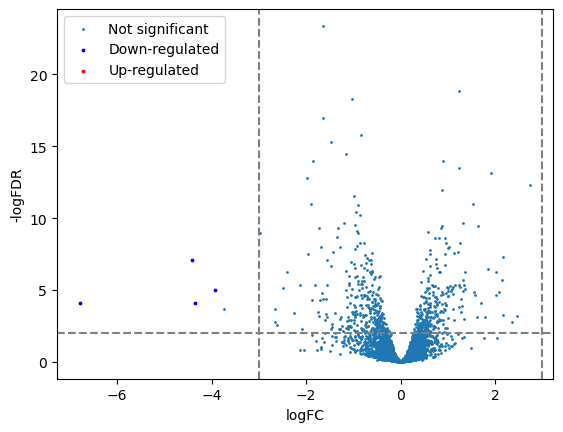

In [29]:
plt.scatter(
    x=full_sorg_results["log2FoldChange"],
    y=full_sorg_results["padj"].apply(lambda x: -np.log10(x)),
    s=1,
    label="Not significant",
)

# highlight down- or up- regulated genes
down_sorg = full_sorg_results[
    (full_sorg_results["log2FoldChange"] <= -3)
    & (full_sorg_results["padj"] <= 0.0001)
]
up_sorg = full_sorg_results[
    (full_sorg_results["log2FoldChange"] >= 3) & (full_sorg_results["padj"] <= 0.0001)
]

plt.scatter(
    x=down_sorg["log2FoldChange"],
    y=down_sorg["padj"].apply(lambda x: -np.log10(x)),
    s=3,
    label="Down-regulated",
    color="blue",
)
plt.scatter(
    x=up_sorg["log2FoldChange"],
    y=up_sorg["padj"].apply(lambda x: -np.log10(x)),
    s=3,
    label="Up-regulated",
    color="red",
)
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axvline(-3, color="grey", linestyle="--")
plt.axvline(3, color="grey", linestyle="--")
plt.axhline(2, color="grey", linestyle="--")
plt.legend()

In [30]:
up_sorg

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj


In [31]:
plt.scatter(
    x=full_results["log2FoldChange"],
    y=full_results["padj"].apply(lambda x: -np.log10(x)),
    s=1,
    label="Not significant",
)

# highlight down- or up- regulated genes
down = full_results[
    (full_results["log2FoldChange"] <= -3) & (full_results["padj"] <= 0.0001)
]
up = full_results[
    (full_results["log2FoldChange"] >= 3) & (full_results["padj"] <= 0.0001)
]

plt.scatter(
    x=down["log2FoldChange"],
    y=down["padj"].apply(lambda x: -np.log10(x)),
    s=3,
    label="Down-regulated",
    color="blue",
)
plt.scatter(
    x=up["log2FoldChange"],
    y=up["padj"].apply(lambda x: -np.log10(x)),
    s=3,
    label="Up-regulated",
    color="red",
)
plt.xlabel("logFC")
plt.ylabel("-logFDR")
plt.axvline(-3, color="grey", linestyle="--")
plt.axvline(3, color="grey", linestyle="--")
plt.axhline(2, color="grey", linestyle="--")
plt.legend()

NameError: name 'full_results' is not defined

In [ ]:
up